## Does local unemployment shape the content and emotional tone of campaign manifestos?
### Party Above All: The Determinants of Emotional Tone in French Campaign Manifestos
#### Author: Salma El-Aazdoudi

> **Two questions:**
> 1. Do candidates in high-unemployment districts *talk more* about unemployment? 
> 2. Do they talk about it with a more *angry / fearful* tone? (emotion scores × LDA)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.decomposition import LatentDirichletAllocation
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary
from statsmodels.nonparametric.smoothers_lowess import lowess

sns.set_theme(style='whitegrid', font_scale=1.1)

CHOMAGE_1992 = {
    '75': 9.5,  '77': 5.8,  '78': 5.3,  '91': 5.5,  '92': 6.7,
    '93': 9.6,  '94': 7.0,  '95': 7.1,  '08': 11.0, '10': 8.8,
    '51': 8.1,  '52': 7.7,  '02': 9.5,  '60': 7.3,  '80': 10.6,
    '27': 8.5,  '76': 10.8, '18': 8.4,  '28': 7.1,  '36': 7.8,
    '37': 8.4,  '41': 7.4,  '45': 6.8,  '14': 8.8,  '50': 7.8,
    '61': 7.0,  '21': 7.6,  '58': 8.3,  '71': 8.5,  '89': 7.9,
    '59': 11.5, '62': 11.7, '54': 7.5,  '55': 6.9,  '57': 7.8,
    '88': 8.3,  '67': 5.3,  '68': 5.1,  '25': 7.5,  '39': 5.3,
    '70': 8.0,  '90': 8.3,  '44': 10.2, '49': 8.5,  '53': 5.6,
    '72': 9.0,  '85': 7.3,  '22': 8.1,  '29': 8.1,  '35': 7.4,
    '56': 8.6,  '16': 9.2,  '17': 11.1, '79': 8.2,  '86': 8.3,
    '24': 8.5,  '33': 9.9,  '40': 7.2,  '47': 9.3,  '64': 8.3,
    '09': 8.5,  '12': 5.5,  '31': 9.0,  '32': 6.4,  '46': 7.1,
    '65': 10.3, '81': 8.1,  '82': 8.3,  '19': 7.6,  '23': 8.0,
    '87': 7.2,  '01': 5.8,  '07': 9.0,  '26': 10.2, '38': 8.8,
    '42': 10.4, '69': 8.3,  '73': 7.3,  '74': 6.7,  '03': 10.6,
    '15': 8.8,  '43': 7.0,  '63': 8.2,  '11': 11.1, '30': 13.0,
    '34': 13.1, '48': 5.3,  '66': 12.7, '04': 8.4,  '05': 7.1,
    '06': 9.3,  '13': 12.7, '83': 11.9, '84': 10.8, '2A': 9.7,
    '2B': 11.4,
}
print('Setup OK')

Setup OK


## 1. LDA — Fit et sélection de K

Loaded: 4,058 docs, 3,000 vocab terms


  K=2 done


  K=3 done


  K=4 done


  K=5 done


...

  K= 5  c_v=0.5403


  K= 6  c_v=0.5388


  K= 7  c_v=0.5560


  K= 8  c_v=0.5518


  K= 9  c_v=0.4990

-> K optimal (coh - stab) : 7
-> K optimal (coh max)    : 2


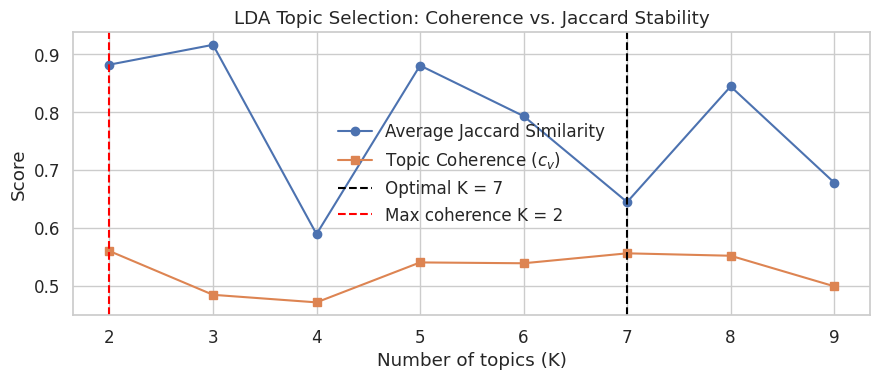


Top words by topic (K=7):
-----------------------------------------------------------------
Topic  0 | coh=0.5773 | front_national, immigration, impôt, immigré, défense, charge, famille, main_propre, réduction, million
Topic  1 | coh=0.8458 | impôt, immigration, front_national, retraite, chômage, emploi, immigration chômage, main, séjour_renouvelable, travail
Topic  2 | coh=0.3313 | emploi, immigration, alliance_populaire, chômage, entreprise, homme, député, européen, création, temps
Topic  3 | coh=0.4365 | communiste, emploi, force, progrès, socialiste, public, chômage, député, service, droit
Topic  4 | coh=0.3924 | emploi, environnement, travail, homme, écologie, député, public, suppléant, maire, chômage
Topic  5 | coh=0.6992 | travailleur, emploi, entreprise, patron, salaire, tour, emploi salaire, compte_banque, salaire entreprise, chômage
Topic  6 | coh=0.6097 | homme, femme, conviction, centre, quotidien, élection_législatif, véritable, difficulté quotidien, solution_concret, hom

In [19]:
with open('preprocessing_output.pkl', 'rb') as f:
    data = pickle.load(f)
dtm       = data['dtm']
vocab     = data['vocab']
df_93     = data['df_93'].copy()
documents = df_93['text_clean']
print(f'Loaded: {dtm.shape[0]:,} docs, {dtm.shape[1]:,} vocab terms')

def get_top_words(model, feature_names, n=15):
    return [[feature_names[i] for i in t.argsort()[:-n-1:-1]] for t in model.components_]

def jaccard(a, b):
    a, b = set(a), set(b)
    return len(a & b) / len(a | b)

tokenized = [str(d).split() for d in documents]
gdict     = Dictionary(tokenized)

K_RANGE = list(range(2, 11))
lda_models, lda_topics = {}, {}
for k in K_RANGE:
    m = LatentDirichletAllocation(
        n_components=k, max_iter=10,
        learning_method='online', learning_offset=50., random_state=42, n_jobs=-1)
    m.fit(dtm)
    lda_models[k] = m
    lda_topics[k] = get_top_words(m, vocab)
    print(f'  K={k} done')

stabilities = []
for i in range(len(K_RANGE)-1):
    k, k1 = K_RANGE[i], K_RANGE[i+1]
    stabilities.append(np.mean([
        max(jaccard(t1, t2) for t2 in lda_topics[k1]) for t1 in lda_topics[k]]))

coherences = []
for k in K_RANGE[:-1]:
    score = CoherenceModel(topics=lda_topics[k], texts=tokenized,
                           dictionary=gdict, coherence='c_v').get_coherence()
    coherences.append(score)
    print(f'  K={k:2d}  c_v={score:.4f}')

diffs    = [coherences[i] - stabilities[i] for i in range(len(coherences)-1)]
K_OPT    = K_RANGE[diffs.index(max(diffs))]
K_COHMAX = K_RANGE[coherences.index(max(coherences))]
print(f'\n-> K optimal (coh - stab) : {K_OPT}')
print(f'-> K optimal (coh max)    : {K_COHMAX}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(K_RANGE[:-1], stabilities, label='Average Jaccard Similarity', marker='o')
ax.plot(K_RANGE[:-1], coherences,  label='Topic Coherence ($c_v$)',    marker='s')
ax.axvline(K_OPT,    color='black', linestyle='--', label=f'Optimal K = {K_OPT}')
ax.axvline(K_COHMAX, color='red',   linestyle='--', label=f'Max coherence K = {K_COHMAX}')
ax.set_xlabel('Number of topics (K)')
ax.set_ylabel('Score')
ax.set_title('LDA Topic Selection: Coherence vs. Jaccard Stability')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('lda_k_selection.png', dpi=150)
plt.show()

N_TOPICS         = K_OPT
lda_final        = lda_models[N_TOPICS]
topic_words      = get_top_words(lda_final, vocab, n=15)
doc_topic_matrix = lda_final.transform(dtm)
coh_per_topic    = CoherenceModel(topics=topic_words, texts=tokenized,
                                   dictionary=gdict, coherence='c_v').get_coherence_per_topic()

print(f'\nTop words by topic (K={N_TOPICS}):')
print('-' * 65)
for i, (words, coh) in enumerate(zip(topic_words, coh_per_topic)):
    print(f'Topic {i:2d} | coh={coh:.4f} | {", ".join(words[:10])}')

In [23]:
# Distribution des blocs par topic dominant
bloc_topic = (
    df_93.groupby(['dominant_topic', 'bloc'])
    .size()
    .unstack(fill_value=0)
)

# En % par topic (normalisation ligne)
bloc_topic_pct = bloc_topic.div(bloc_topic.sum(axis=1), axis=0).round(3) * 100

print('Distribution des blocs par topic dominant (%) :')
display(bloc_topic_pct)

# Heatmap
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(bloc_topic_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax)
ax.set_title('% de chaque bloc par topic dominant\n(lecture en ligne = 100%)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Bloc'); ax.set_ylabel('Topic dominant')
plt.tight_layout()
plt.savefig('bloc_par_topic.png', dpi=150)
plt.show()

KeyError: 'dominant_topic'

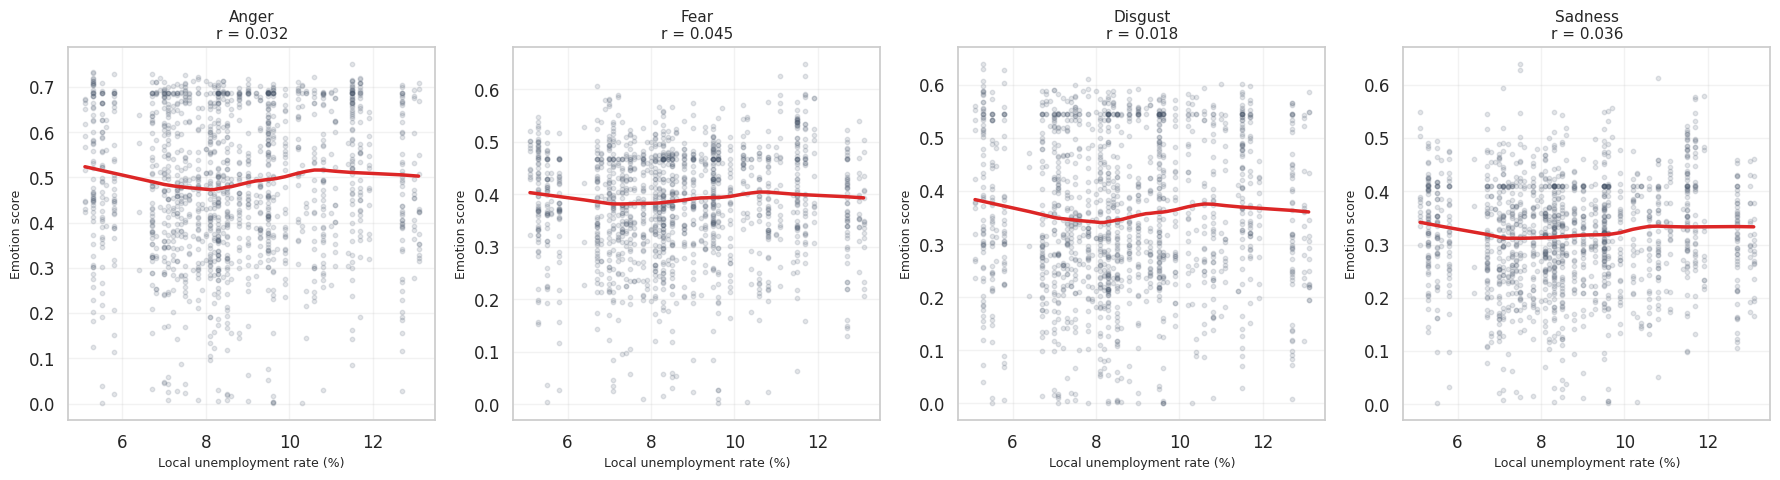

In [18]:
EMO_LABELS = {
    'tr_anger':   'Anger',
    'tr_fear':    'Fear',
    'tr_disgust': 'Disgust',
    'tr_sadness': 'Sadness'
}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, col in zip(axes, EMO_COLS):
    d = df_chomage.dropna(subset=['chomage_dept', col])
    ax.scatter(d['chomage_dept'], d[col], alpha=0.15, s=10, color='#475569')
    tr = lowess(d[col].values, d['chomage_dept'].values, frac=0.6)
    ax.plot(tr[:,0], tr[:,1], color='#DC2626', lw=2.5)
    r = np.corrcoef(d['chomage_dept'], d[col])[0,1]
    ax.set_title(f'{EMO_LABELS[col]}\nr = {r:.3f}', fontsize=11)
    ax.set_xlabel('Local unemployment rate (%)', fontsize=9)
    ax.set_ylabel('Emotion score', fontsize=9)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('scatter_chomage_emotions.png', dpi=150)
plt.show()

In [21]:
BLOC_COLORS = {
    'far_left'  : '#7C3AED',
    'left'      : '#2563EB',
    'ecologist' : '#16A34A',
    'right'     : '#DC2626',
    'far_right' : '#F97316',
}

TOPIC_LABELS = {
    0: 'T0 — Nationalist identity',
    1: 'T1 — Nationalist grievance',
    2: 'T2 — Far-right catch-all',
    3: 'T3 — Institutional left',
    4: 'T4 — Cross-bloc catch-all',
    5: 'T5 — Conflictual labour',
    6: 'T6 — Mainstream right',
}

# Rebuild pct table with topic labels
bloc_pct = (
    df_93.groupby(['dominant_topic', 'bloc'])
    .size()
    .unstack(fill_value=0)
    .div(df_93.groupby('dominant_topic').size(), axis=0) * 100
)
bloc_pct.index = [TOPIC_LABELS[i] for i in bloc_pct.index]

fig, ax = plt.subplots(figsize=(10, 5))

left = np.zeros(len(bloc_pct))
for bloc in ['far_left', 'left', 'ecologist', 'right', 'far_right']:
    if bloc not in bloc_pct.columns:
        continue
    vals = bloc_pct[bloc].values
    bars = ax.barh(bloc_pct.index, vals, left=left,
                   color=BLOC_COLORS[bloc], label=bloc.replace('_', ' ').title())
    # Label inside bar if wide enough
    for i, (v, l) in enumerate(zip(vals, left)):
        if v > 5:
            ax.text(l + v/2, i, f'{v:.0f}%', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
    left += vals

ax.set_xlim(0, 100)
ax.set_xlabel('Share of manifestos (%)', fontsize=10)
ax.set_title('Partisan composition of each LDA topic\n(% of manifestos by bloc)',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', frameon=False, fontsize=9)
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
plt.savefig('topic_bloc_composition.png', dpi=150)
plt.show()

KeyError: 'dominant_topic'

In [22]:
# Part de manifestes à topic emploi par groupe de chômage réel
df_93['is_chomage_topic'] = df_93['dominant_topic'].isin([1, 3, 5])

pct = (
    df_93.dropna(subset=['chomage_dept'])
    .assign(chomage_groupe=lambda x: pd.Categorical(
        x['chomage_dept'].apply(chomage_groupe),
        categories=GROUPE_ORDER, ordered=True))
    .groupby('chomage_groupe', observed=True)['is_chomage_topic']
    .agg(['mean', 'count'])
    .assign(pct=lambda x: x['mean'] * 100)
    .round(1)
)
pct.columns = ['proportion', 'n_manifestes', 'pct (%)']
print('Part de manifestes à topic dominant emploi/chômage par groupe :')
display(pct)

KeyError: 'dominant_topic'